In [3]:
import pandas as pd 

df = pd.read_csv("data/HI-Small_Trans.csv")
print(df.shape)
df.head()

(5078345, 11)


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


In [4]:
print(df.columns.tolist())
print("Transaction: ", len(df))
print("Laundering: ", df["Is Laundering"].sum())
print("Rate: 1 in", round(len(df) / df["Is Laundering"].sum()))

['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering']
Transaction:  5078345
Laundering:  5177
Rate: 1 in 981


In [5]:
senders = df["Account"].nunique()
receivers = df["Account.1"].nunique()
print("Unique Senders: ", senders, "| Unique Receivers:", receivers)


Unique Senders:  496995 | Unique Receivers: 420636


In [6]:
df["Amount Paid"].describe()

count    5.078345e+06
mean     4.509273e+06
std      8.697728e+08
min      1.000000e-06
25%      1.844800e+02
50%      1.414540e+03
75%      1.229784e+04
max      1.046302e+12
Name: Amount Paid, dtype: float64

In [7]:
df.groupby("Is Laundering")["Amount Paid"].median()

Is Laundering
0    1410.99
1    8667.21
Name: Amount Paid, dtype: float64

In [8]:
import networkx as nx
import matplotlib.pyplot as plt

laund = df[df["Is Laundering"] == 1]
counts = laund["Account"].value_counts()
target = counts[(counts >= 3) & (counts <= 10)].index[0]
print("Target Account: ", target)

Target Account:  812D0C600


In [9]:
hop1 = df[(df["Account"] == target) | (df["Account.1"] == target)]
partners = set(hop1["Account"]) | set(hop1["Account.1"])

neighbors = df[(df["Account"].isin(partners)) & (df["Account.1"].isin(partners))]
print(len(neighbors), "transactions in the 2-hop neighborhood of", target)

67 transactions in the 2-hop neighborhood of 812D0C600


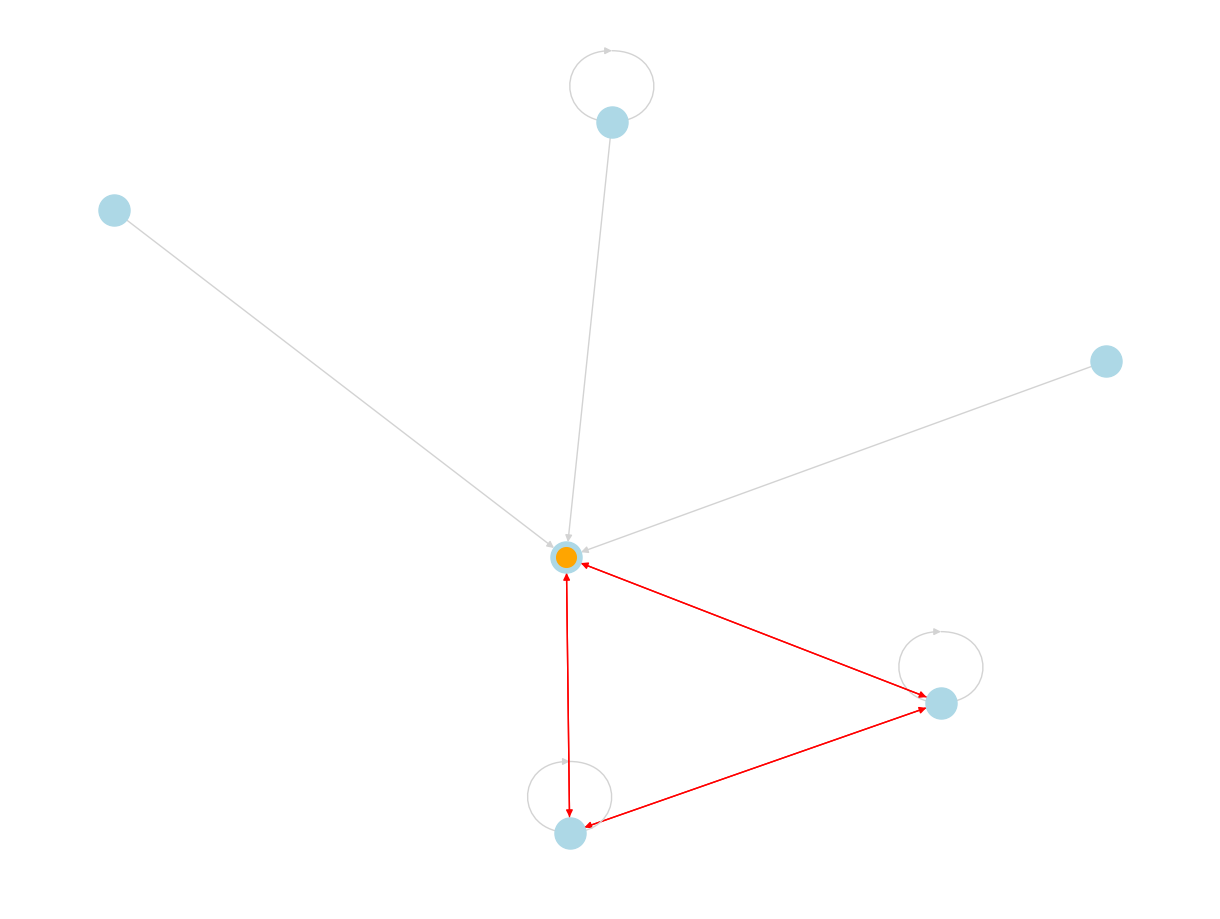

In [10]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.from_pandas_edgelist(neighbors, "Account", "Account.1", edge_attr="Is Laundering", create_using=nx.DiGraph())

colours = ["red" if G[u][v]["Is Laundering"] else "lightgrey" for u, v in G.edges()]

plt.figure(figsize=(12, 9))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, edge_color=colours, node_size=500, node_color="lightblue", arrows=True)
nx.draw_networkx_nodes(G, pos, nodelist=[target], node_color="orange", node_size=200)
plt.show()

In [11]:
print(neighbors["Is Laundering"].value_counts())
a =neighbors[neighbors["Is Laundering"] == 1][["Account", "Account.1", "Amount Paid"]].head(10)
print(a)

Is Laundering
1    39
0    28
Name: count, dtype: int64
           Account  Account.1  Amount Paid
444467   811FFF630  812D0C3C0     69301.15
444468   812D0C600  812D0C3C0      8608.45
444469   812D0C3C0  811FFF630     30234.15
444470   812D0C3C0  812D0C600     21901.40
595312   811FFF630  812D0C3C0     72231.01
595314   812D0C600  812D0C3C0     13292.95
1030762  812D0C600  812D0C3C0     33328.15
1030763  812D0C3C0  812D0C600     31881.74
1577271  812D0C3C0  811FFF630      1549.95
1577272  811FFF630  812D0C3C0      1648.28


In [12]:
target_2 = counts[(counts >= 3) & (counts <= 10)].index[1]
print("Target Account: ", target_2)

Target Account:  8001BB380


In [13]:
hop1_2 = df[(df["Account"] == target_2) | (df["Account.1"] == target_2)]
partners_2 = set(hop1_2["Account"]) | set(hop1_2["Account.1"])

neighbors_2 = df[(df["Account"].isin(partners_2)) & (df["Account.1"].isin(partners_2))]
print(len(neighbors_2), "transactions in the 2-hop neighborhood of", target_2)

325 transactions in the 2-hop neighborhood of 8001BB380


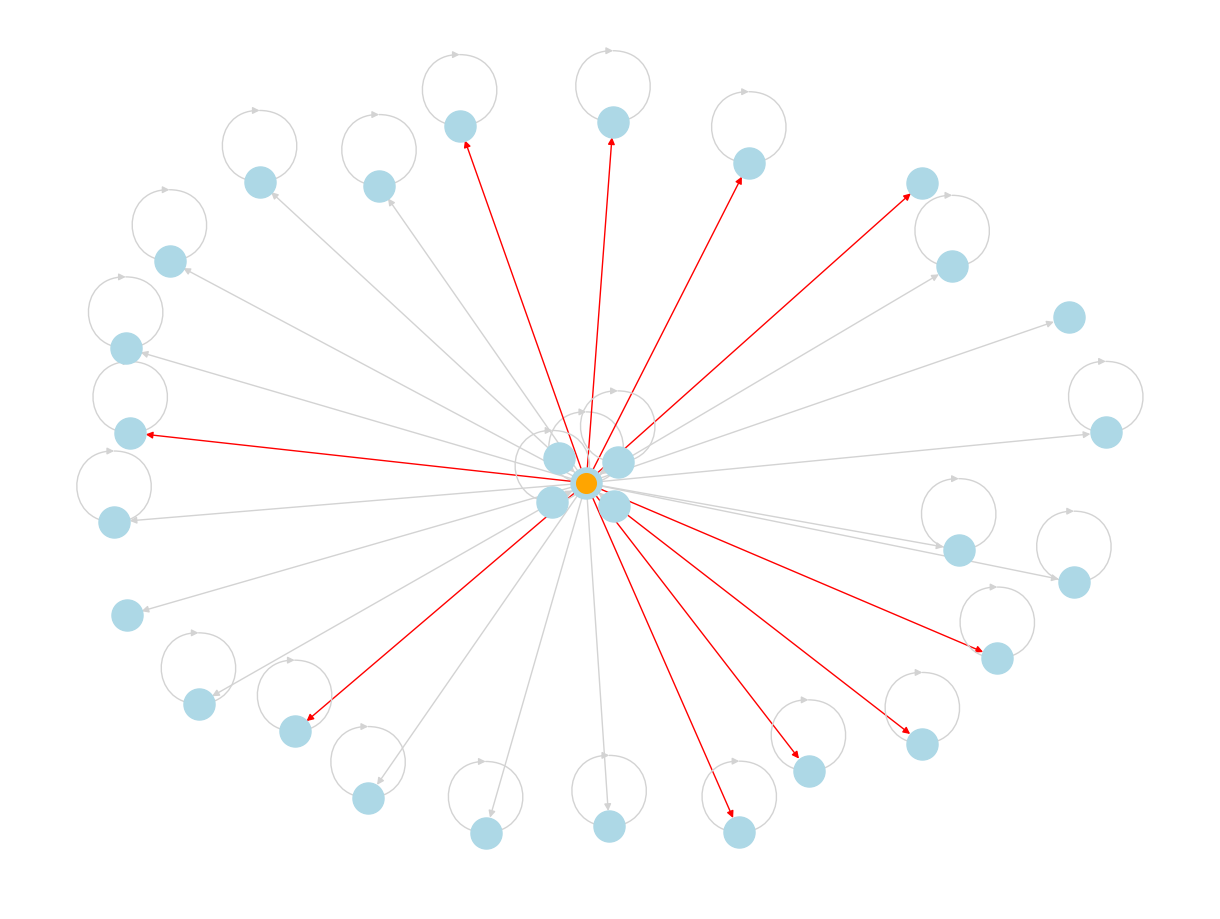

In [14]:
G = nx.from_pandas_edgelist(neighbors_2, "Account", "Account.1", edge_attr="Is Laundering", create_using=nx.DiGraph())

colours = ["red" if G[u][v]["Is Laundering"] else "lightgrey" for u, v in G.edges()]

plt.figure(figsize=(12, 9))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, edge_color=colours, node_size=500, node_color="lightblue", arrows=True)
nx.draw_networkx_nodes(G, pos, nodelist=[target_2], node_color="orange", node_size=200)
plt.show()

In [15]:
red_case = neighbors_2[neighbors_2["Is Laundering"] == 1][["Account", "Account.1", "Amount Paid"]]
print(red_case)

          Account  Account.1  Amount Paid
903799  8001BB380  8001A6870      1499.02
903801  8001BB380  8001D8590      2380.42
903803  8001BB380  8002185A0      1547.24
903805  8001BB380  80022FC00      9947.89
903806  8001BB380  80016DA30      9940.77
903808  8001BB380  800550B60      5851.21
903810  8001BB380  8000FBD00      3946.65
903812  8001BB380  80017BE40      5035.99
903814  8001BB380  80011F990     14351.99
903816  8001BB380  8001B0770     14136.49


In [42]:
print("1 in", round(len(df) / df["Is Laundering"].sum()))
df.groupby("Is Laundering")["Amount Paid"].median()

1 in 981


Is Laundering
0    1410.99
1    8667.21
Name: Amount Paid, dtype: float64

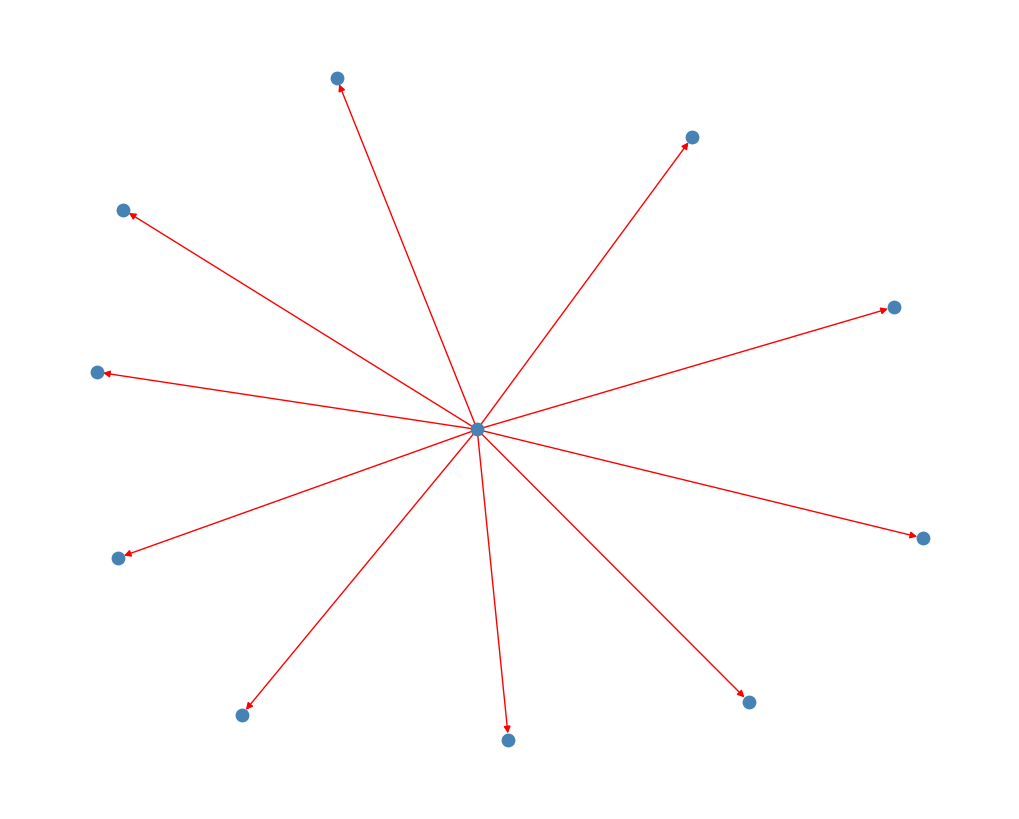

In [16]:
dirty = neighbors_2[neighbors_2["Is Laundering"] == 1]
Gd = nx.from_pandas_edgelist(dirty, "Account", "Account.1", create_using=nx.DiGraph)

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(Gd, seed=42)
nx.draw(Gd, pos, node_size=80, node_color="steelblue", edge_color="red", arrows=True)
plt.show()

In [17]:
sent = df.groupby("Account").agg(
    n_sent=("Account.1", "size"),
    n_receivers=("Account.1", "nunique"),
    total_sent=("Amount Paid", "sum"),
).reset_index().rename(columns={"Account": "acct"})

recv = df.groupby("Account.1").agg(
    n_received=("Account", "size"),
    n_senders=("Account", "nunique"),
    total_received=("Amount Received", "sum"),
).reset_index().rename(columns={"Account.1": "acct"})

feats = sent.merge(recv, on="acct", how="outer").fillna(0)
print(feats.columns.tolist())
feats.sort_values("total_sent", ascending=False).head(10)



['acct', 'n_sent', 'n_receivers', 'total_sent', 'n_received', 'n_senders', 'total_received']


,acct,n_sent,n_receivers,total_sent,n_received,n_senders,total_received
23017,800E8B7F0,83.0,7.0,1.505696e+12,34.0,9.0,1.486636e+12
142416,8059FB490,47.0,3.0,1.086461e+12,47.0,4.0,1.072676e+12
97627,803D95360,2.0,2.0,1.061322e+12,2.0,2.0,1.501986e+10
38293,801832F80,10.0,4.0,1.026818e+12,26.0,4.0,1.013024e+12
120408,804C1CD70,3.0,2.0,9.670396e+11,2.0,1.0,1.106324e+09
36393,8017047B0,105.0,5.0,4.473341e+11,48.0,3.0,4.413240e+11
154159,80616FF00,58.0,4.0,3.848889e+11,18.0,5.0,3.799869e+11
4,100428780,17264.0,1421.0,3.739337e+11,117.0,61.0,1.057089e+07
101792,804033940,98.0,7.0,2.883483e+11,36.0,3.0,1.483228e+10
3,100428738,13756.0,1136.0,2.592168e+11,98.0,51.0,6.304388e+06


In [18]:
bad_senders = df[df["Is Laundering"] == 1]["Account"].unique()
bad_receivers = df[df["Is Laundering"] == 1]["Account.1"].unique()
bad = set(bad_senders) | set(bad_receivers)

feats["is_bad"] = feats["acct"].isin(bad).astype(int)
print("Flagged accounts: ", feats["is_bad"].sum(), "out of", len(feats))

feats.groupby("is_bad").mean(numeric_only=True)

Flagged accounts:  6357 out of 515080


,n_sent,n_receivers,total_sent,n_received,n_senders,total_received
is_bad,,,,,,
0,8.899413,1.885504,4.228498e+07,9.781675,1.943339,5.893002e+07
1,86.677521,8.893661,2.183896e+08,16.073934,4.265377,6.823325e+07


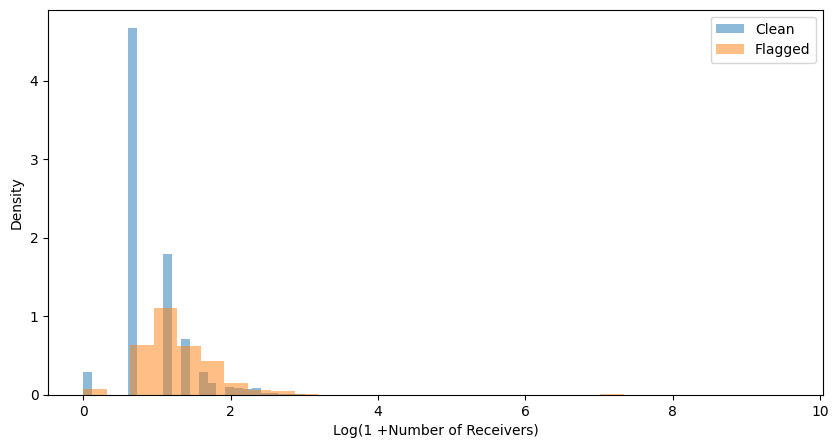

In [19]:
import numpy as np

plt.figure(figsize=(10, 5))
for label, name in [(0, "Clean"), (1, "Flagged")]:
    vals = feats[feats["is_bad"] == label]["n_receivers"]
    plt.hist(np.log1p(vals), bins=30, alpha=0.5, density=True, label=name)
plt.xlabel("Log(1 +Number of Receivers)")
plt.ylabel("Density")
plt.legend()
plt.show()

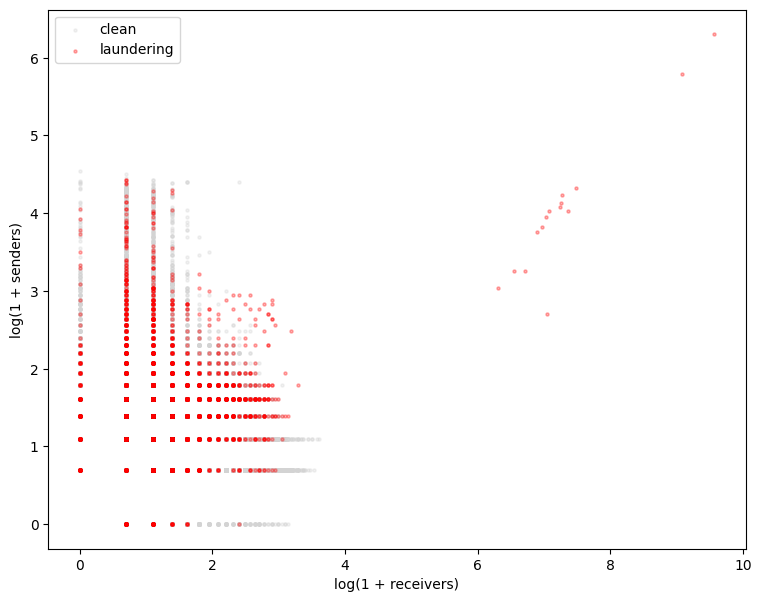

In [20]:

plt.figure(figsize=(9, 7))
for label, name, col in [(0, "clean", "lightgray"), (1, "laundering", "red")]:
    sub = feats[feats["is_bad"] == label]
    plt.scatter(np.log1p(sub["n_receivers"]), np.log1p(sub["n_senders"]),
                s=5, alpha=0.3, c=col, label=name)
plt.xlabel("log(1 + receivers)")
plt.ylabel("log(1 + senders)")
plt.legend()
plt.show()

In [21]:
feats["sender_receiver_ratio"] = (feats["n_senders"] + 1) / (feats["n_receivers"] + 1)
feats["total_throughput"] = feats["total_sent"] + feats["total_received"]
feats["in_out_ratio"] = (feats["total_received"] + 1) / (feats["total_sent"] + 1)

feats.groupby("is_bad")[["sender_receiver_ratio", "in_out_ratio"]].median()

,sender_receiver_ratio,in_out_ratio
is_bad,,
0,1.0,1.000000
1,1.2,1.006273


In [22]:
from sklearn.model_selection import train_test_split

features = ["n_sent", "n_receivers", "total_sent",
            "n_received", "n_senders", "total_received",
            "sender_receiver_ratio", "total_throughput"]

X = feats[features]
y = feats["is_bad"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Laundering in train:", y_train.sum(), " in test:", y_test.sum())

Train: (360556, 8)  Test: (154524, 8)
Laundering in train: 4450  in test: 1907


In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

model = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1)
# class_weight 1-80 is fraud so model needs to be right as often as possible and laziest way to be right 99% of the time is to call every single account clean
model.fit(X_train, y_train)
preds = model.predict(X_test)
print(classification_report(y_test, preds, digits=3))




              precision    recall  f1-score   support

           0      0.988     1.000     0.994    152617
           1      0.301     0.015     0.028      1907

    accuracy                          0.987    154524
   macro avg      0.644     0.507     0.511    154524
weighted avg      0.979     0.987     0.982    154524



In [24]:
import pandas as pd
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print(importances)

total_received           0.186678
total_throughput         0.172751
total_sent               0.162826
n_received               0.152771
n_sent                   0.093135
n_receivers              0.090837
n_senders                0.085886
sender_receiver_ratio    0.055115
dtype: float64


In [25]:
out_partners = df.groupby("Account")["Account.1"].agg(set)
in_partners = df.groupby("Account.1")["Account"].agg(set)

def reciprocity(acct):
    outs = out_partners.get(acct, set())
    ins = in_partners.get(acct, set())
    if not outs:
        return 0
    return len(outs & ins) / len(outs)

feats["reciprocity"] = feats["acct"].map(reciprocity)
feats.groupby("is_bad")["reciprocity"].median()

print(feats["reciprocity"].describe())
print(feats.groupby("is_bad")["reciprocity"].mean())
print((feats["reciprocity"] == 0).mean(), "fraction exactly 0")

count    515080.000000
mean          0.513748
std           0.417902
min           0.000000
25%           0.000000
50%           0.500000
75%           1.000000
max           1.000000
Name: reciprocity, dtype: float64
is_bad
0    0.514307
1    0.468988
Name: reciprocity, dtype: float64
0.2839655975770754 fraction exactly 0


In [26]:
with open("data/HI-Small_Patterns.txt") as f:
    for i in range (30):
        print(f.readline().rstrip())

BEGIN LAUNDERING ATTEMPT - FAN-OUT:  Max 16-degree Fan-Out
2022/09/01 00:06,021174,800737690,012,80011F990,2848.96,Euro,2848.96,Euro,ACH,1
2022/09/01 04:33,021174,800737690,020,80020C5B0,8630.40,Euro,8630.40,Euro,ACH,1
2022/09/01 09:14,021174,800737690,020,80006A5E0,35642.49,Yuan,35642.49,Yuan,ACH,1
2022/09/01 09:56,021174,800737690,00220,8007A5B70,5738987.96,US Dollar,5738987.96,US Dollar,ACH,1
2022/09/01 11:28,021174,800737690,001244,80093C0D0,7254.53,US Dollar,7254.53,US Dollar,ACH,1
2022/09/01 13:13,021174,800737690,00513,80078E200,6990.87,US Dollar,6990.87,US Dollar,ACH,1
2022/09/01 14:11,021174,800737690,020,80066B990,12536.92,Euro,12536.92,Euro,ACH,1
2022/09/02 15:40,021174,800737690,00410,8002CC310,3511.82,Euro,3511.82,Euro,ACH,1
2022/09/02 21:23,021174,800737690,01292,8004030A0,16135.09,US Dollar,16135.09,US Dollar,ACH,1
2022/09/02 23:10,021174,800737690,01601,800578800,12183.28,US Dollar,12183.28,US Dollar,ACH,1
2022/09/03 09:29,021174,800737690,001,800AAF0B0,15197.45,US Doll

In [27]:
from collections import Counter

attempts = Counter()
tx_counts = Counter()
current = None

with open("data/HI-Small_Patterns.txt") as f:
    for line in f:
        line = line.strip()
        if line.startswith("BEGIN LAUNDERING ATTEMPT"):
            current = line.split("-", 1)[1].split(":")[0].strip()
            attempts[current] += 1
        elif line.startswith("END LAUNDERING ATTEMPT"):
            current = None 
        elif line and current:
            tx_counts[current] += 1

print("Attempts per pattern: ")
for p, n in attempts.most_common():
    print(f" {p:20s} {n:5d} attempts, {tx_counts[p]:6d} transactions")

Attempts per pattern: 
 CYCLE                   54 attempts,    287 transactions
 GATHER-SCATTER          51 attempts,    716 transactions
 BIPARTITE               49 attempts,    263 transactions
 FAN-OUT                 48 attempts,    342 transactions
 SCATTER-GATHER          44 attempts,    626 transactions
 STACK                   43 attempts,    466 transactions
 RANDOM                  41 attempts,    191 transactions
 FAN-IN                  40 attempts,    318 transactions


In [28]:
feats["degree"] = feats["n_senders"] + feats["n_receivers"]

feats["fan_imbalance"] = (feats["n_senders"] - feats["n_receivers"]).abs()

feats["passthrough"] = feats[["n_senders", "n_receivers"]].min(axis=1)

feats.groupby("is_bad")[["degree", "fan_imbalance", "passthrough"]].median()




,degree,fan_imbalance,passthrough
is_bad,,,
0,3.0,1.0,1.0
1,6.0,2.0,2.0


In [29]:
features = ["n_sent", "n_receivers", "total_sent",
            "n_received", "n_senders", "total_received",
            "sender_receiver_ratio", "total_throughput",
            "degree", "fan_imbalance", "passthrough"]

X = feats[features]
y = feats["is_bad"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)

model = RandomForestClassifier(
    n_estimators=100, class_weight="balanced",
    random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
preds = model.predict(X_test)


print(classification_report(y_test, preds, digits=3))


              precision    recall  f1-score   support

           0      0.988     0.999     0.994    152617
           1      0.279     0.016     0.031      1907

    accuracy                          0.987    154524
   macro avg      0.634     0.508     0.512    154524
weighted avg      0.979     0.987     0.982    154524



In [30]:
probs = model.predict_proba(X_test)[:, 1]
for threshold in [0.5, 0.3, 0.2, 0.1, 0.05]:
    preds_t = (probs >= threshold).astype(int)
    rep = classification_report(y_test, preds_t, output_dict=True, zero_division=0)
    p = rep["1"]["precision"]
    r = rep["1"]["recall"]
    print(f"threshold {threshold:.2f}  ->  precision {p:.3f}   recall {r:.3f}")


threshold 0.50  ->  precision 0.279   recall 0.018
threshold 0.30  ->  precision 0.170   recall 0.044
threshold 0.20  ->  precision 0.117   recall 0.077
threshold 0.10  ->  precision 0.080   recall 0.185
threshold 0.05  ->  precision 0.058   recall 0.320


In [31]:
import lightgbm as lgb

ratio = (y_train == 0).sum() / (y_train == 1).sum()
print("imbalance ratio: ", round(ratio))

model_lgb = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    scale_pos_weight=ratio,
    random_state=42,
    n_jobs=-1)

model_lgb.fit(X_train, y_train)

probs = model_lgb.predict_proba(X_test)[:, 1]

for threshold in [0.5, 0.3, 0.2, 0.1, 0.05]:
    preds_t = (probs >= threshold).astype(int)
    rep = classification_report(y_test, preds_t, output_dict=True, zero_division=0)
    print(f"threshold {threshold:.2f}  ->  precision {rep['1']['precision']:.3f} recall {rep['1']['recall']:.3f}")

imbalance ratio:  80
[LightGBM] [Info] Number of positive: 4450, number of negative: 356106
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001757 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1508
[LightGBM] [Info] Number of data points in the train set: 360556, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.012342 -> initscore=-4.382324
[LightGBM] [Info] Start training from score -4.382324
threshold 0.50  ->  precision 0.041 recall 0.738
threshold 0.30  ->  precision 0.029 recall 0.883
threshold 0.20  ->  precision 0.023 recall 0.952
threshold 0.10  ->  precision 0.020 recall 0.985
threshold 0.05  ->  precision 0.019 recall 0.993


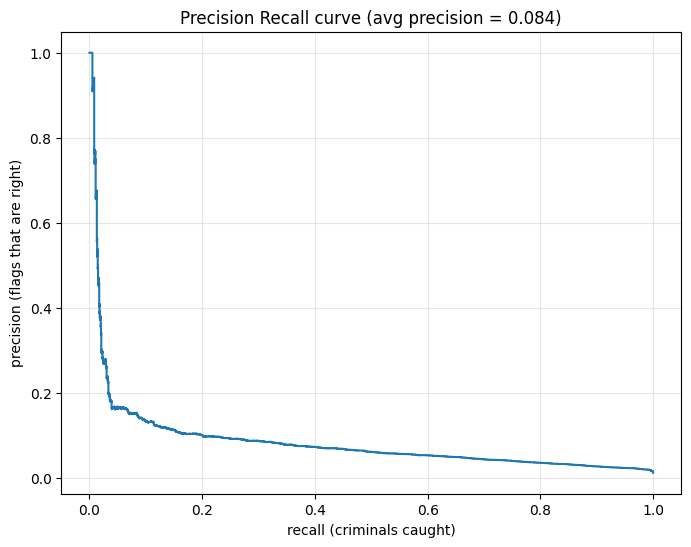

In [32]:
from sklearn.metrics import precision_recall_curve, average_precision_score

prec, rec, thr = precision_recall_curve(y_test, probs)
ap = average_precision_score(y_test, probs)

plt.figure(figsize=(8, 6))
plt.plot(rec, prec)
plt.xlabel("recall (criminals caught)")
plt.ylabel("precision (flags that are right)")
plt.title(f"Precision Recall curve (avg precision = {ap:.3f})")
plt.grid(True, alpha=0.3)
plt.show()

In [33]:
import networkx as nx 

G = nx.from_pandas_edgelist(df, "Account", "Account.1", create_using=nx.DiGraph())
print("Nodes: ", G.number_of_nodes(), "Edges: ", G.number_of_edges())


Nodes:  515080 Edges:  1015736


In [34]:
sccs = [c for c in nx.strongly_connected_components(G) if len(c) > 1]
cycle_nodes = set().union(*sccs) if sccs else set()
print("Accounts that sit on a cycle: ", len(cycle_nodes))

feats["on_cycle"] = feats["acct"].isin(cycle_nodes).astype(int)
feats.groupby("is_bad")["on_cycle"].mean()


Accounts that sit on a cycle:  23247


is_bad
0    0.042597
1    0.248073
Name: on_cycle, dtype: float64

In [35]:
feats["graph_in_degree"] = feats["acct"].map(dict(G.in_degree())).fillna(0)
feats["graph_out_degree"] = feats["acct"].map(dict(G.out_degree())).fillna(0)

pr = nx.pagerank(G, alpha=0.85)
feats["pagerank"] = feats["acct"].map(pr).fillna(0)

feats.groupby("is_bad")[["graph_in_degree", "graph_out_degree", "pagerank"]].median()
feats.groupby("is_bad")["pagerank"].median().apply(lambda x: f"{x:.2e}")



is_bad
0    1.67e-06
1    1.71e-06
Name: pagerank, dtype: str

[LightGBM] [Info] Number of positive: 4450, number of negative: 356106
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002879 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1869
[LightGBM] [Info] Number of data points in the train set: 360556, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.012342 -> initscore=-4.382324
[LightGBM] [Info] Start training from score -4.382324
Average precision: 0.101  (was 0.084 without graph features)


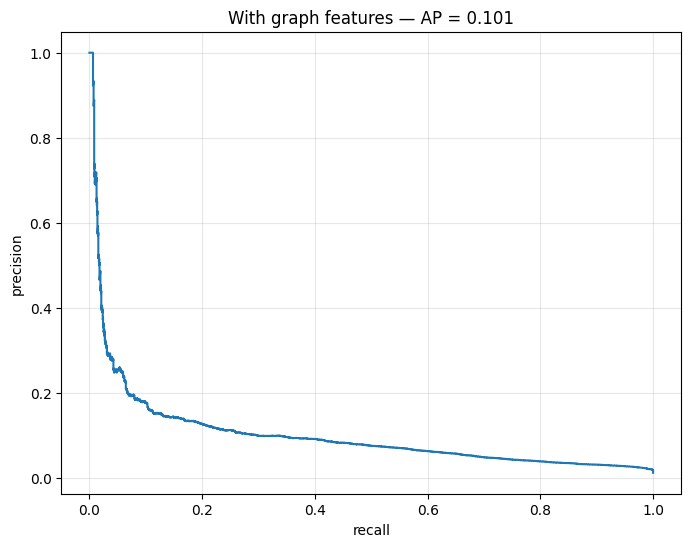

In [36]:
features = ["n_sent", "n_receivers", "total_sent",
            "n_received", "n_senders", "total_received",
            "sender_receiver_ratio", "total_throughput",
            "degree", "fan_imbalance", "passthrough",
            "on_cycle", "graph_in_degree", "graph_out_degree", "pagerank"]

X = feats[features]
y = feats["is_bad"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)

ratio = (y_train == 0).sum() / (y_train == 1).sum()
model_lgb = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05,
    scale_pos_weight=ratio, random_state=42, n_jobs=-1)
model_lgb.fit(X_train, y_train)
probs = model_lgb.predict_proba(X_test)[:, 1]

from sklearn.metrics import precision_recall_curve, average_precision_score
prec, rec, thr = precision_recall_curve(y_test, probs)
ap = average_precision_score(y_test, probs)
print("Average precision:", round(ap, 3), " (was 0.084 without graph features)")

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.plot(rec, prec)
plt.xlabel("recall"); plt.ylabel("precision")
plt.title(f"With graph features — AP = {ap:.3f}")
plt.grid(True, alpha=0.3)
plt.show()

In [37]:
import pandas as pd
imp = pd.Series(model_lgb.feature_importances_, index=features).sort_values(ascending=False)
print(imp)

pagerank                 1635
total_received           1246
total_sent               1208
n_received               1118
n_sent                   1066
total_throughput          915
degree                    485
sender_receiver_ratio     442
n_receivers               248
n_senders                 248
fan_imbalance             144
passthrough               126
on_cycle                  119
graph_in_degree             0
graph_out_degree            0
dtype: int32


In [38]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.sort_values("Timestamp")

cutoff = df["Timestamp"].quantile(0.7)
train_tx = df[df["Timestamp"] <= cutoff]
test_tx = df[df["Timestamp"] > cutoff]

print("Train tx: ", len(train_tx), "Test tx: ", len(test_tx))
print("Train laundering: ", train_tx["Is Laundering"].sum(),
    "Test Laundering: ", test_tx["Is Laundering"].sum())

Train tx:  3554957 Test tx:  1523388
Train laundering:  2856 Test Laundering:  2321


In [39]:
def build_all_features(tx):
    sent = tx.groupby("Account").agg(
        n_sent=("Account.1", "size"),
        n_receivers=("Account.1", "nunique"),
        total_sent=("Amount Paid", "sum"),
    ).reset_index().rename(columns={"Account": "acct"})
    recv = tx.groupby("Account.1").agg(
        n_received=("Account", "size"),
        n_senders=("Account", "nunique"),
        total_received=("Amount Received", "sum"),
    ).reset_index().rename(columns={"Account.1": "acct"})
    f = sent.merge(recv, on="acct", how="outer").fillna(0)

    f["sender_receiver_ratio"] = (f["n_senders"] + 1) / (f["n_receivers"] + 1)
    f["total_throughput"] = f["total_sent"] + f["total_received"]
    f["degree"] = f["n_senders"] + f["n_receivers"]
    f["fan_imbalance"] = (f["n_senders"] - f["n_receivers"]).abs()
    f["passthrough"] = f[["n_senders", "n_receivers"]].min(axis=1)

    g = nx.from_pandas_edgelist(tx, "Account", "Account.1", create_using=nx.DiGraph())
    sccs = [c for c in nx.strongly_connected_components(g) if len(c) > 1]
    cycle_nodes = set().union(*sccs) if sccs else set()
    f["on_cycle"] = f["acct"].isin(cycle_nodes).astype(int)
    pr = nx.pagerank(g, alpha=0.85)
    f["pagerank"] = f["acct"].map(pr).fillna(0)
    return f

def add_label(f, tx):
    bad = set(tx[tx["Is Laundering"] == 1]["Account"]) | \
          set(tx[tx["Is Laundering"] == 1]["Account.1"])
    f["is_bad"] = f["acct"].isin(bad).astype(int)
    return f

train = add_label(build_all_features(train_tx), train_tx)
test  = add_label(build_all_features(test_tx),  test_tx)
print("Train accounts:", len(train), " bad:", train["is_bad"].sum())
print("Test accounts: ", len(test),  " bad:", test["is_bad"].sum())




Train accounts: 513284  bad: 3857
Test accounts:  363776  bad: 2844


[LightGBM] [Info] Number of positive: 3857, number of negative: 509427
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003282 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1643
[LightGBM] [Info] Number of data points in the train set: 513284, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.007514 -> initscore=-4.883397
[LightGBM] [Info] Start training from score -4.883397
Average precision (TIME split): 0.043  (random split was 0.101)


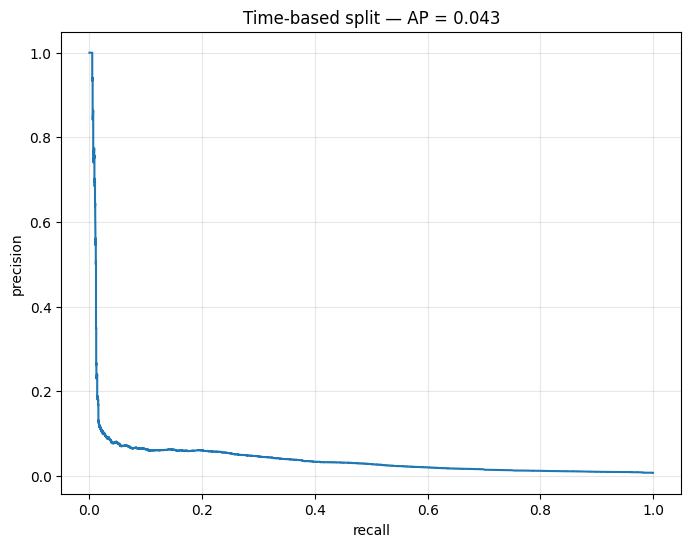

In [40]:
features = ["n_sent", "n_receivers", "total_sent",
            "n_received", "n_senders", "total_received",
            "sender_receiver_ratio", "total_throughput",
            "degree", "fan_imbalance", "passthrough",
            "on_cycle", "pagerank"]

X_train, y_train = train[features], train["is_bad"]
X_test,  y_test  = test[features],  test["is_bad"]

ratio = (y_train == 0).sum() / (y_train == 1).sum()
model_lgb = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05,
    scale_pos_weight=ratio, random_state=42, n_jobs=-1)
model_lgb.fit(X_train, y_train)
probs = model_lgb.predict_proba(X_test)[:, 1]

from sklearn.metrics import precision_recall_curve, average_precision_score
prec, rec, thr = precision_recall_curve(y_test, probs)
ap = average_precision_score(y_test, probs)
print("Average precision (TIME split):", round(ap, 3), " (random split was 0.101)")

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.plot(rec, prec)
plt.xlabel("recall"); plt.ylabel("precision")
plt.title(f"Time-based split — AP = {ap:.3f}")
plt.grid(True, alpha=0.3)
plt.show()

In [43]:
feats.to_csv("feats_for_gnn.csv", index=False)
df[["Account", "Account.1", "Is Laundering"]].to_csv("edges_for_gnn.csv", index=False)
print("saved")

saved
